In [1]:
%matplotlib inline

# Лабораторная работа №4. Клеточные автоматы

**Дисциплина:** Теория систем

## Цель работы
Изучить принципы функционирования клеточных автоматов и приобрести навыки их
программной реализации. Реализуются элементарный одномерный автомат Вольфрама
(правила 30, 90, 110) и двумерный автомат Конвея «Жизнь», проводится серия
численных экспериментов с поиском времени стабилизации и классификацией фигур.

## Задачи
1. Реализовать элементарный одномерный клеточный автомат с произвольным правилом.
2. Реализовать модель игры «Жизнь» Конвея на квадратной решётке.
3. Провести серию экспериментов со случайным заполнением, оценить среднее время
   стабилизации в зависимости от плотности.
4. Классифицировать возникающие фигуры и сопоставить их с известными паттернами.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import label, convolve

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
np.set_printoptions(linewidth=120)

## Архитектура программных моделей

Модели разделены по принципу единственной ответственности (диаграмма классов
в отчёте, рисунок 1):

- **`ElementaryCA`** — ядро одномерного автомата: один шаг и эволюция.
- **`GameOfLife`** — ядро игры «Жизнь»: один шаг и детектор стабилизации.
- **`PatternClassifier`** — классификация изолированных объектов, работает
  поверх `GameOfLife` (использует его `step()` для прогона компонент).
- **`ElemCAExperiment`**, **`DensityExperiment`**, **`ClassificationExp`** —
  экспериментальные модули: не содержат основного алгоритма, а готовят входы
  и отрисовывают результаты, вызывая соответствующее ядро.

## 1. Элементарный одномерный клеточный автомат

In [3]:
class ElementaryCA:
    """Ядро элементарного одномерного автомата Вольфрама с периодическими границами."""

    def __init__(self, rule, state):
        self.rule = rule
        self.table = self.rule_to_table(rule)
        self.state = np.asarray(state, dtype=np.uint8).copy()

    @staticmethod
    def rule_to_table(rule_number):
        """Номер правила (0..255) -> таблица переходов из 8 битов."""
        return np.array([(rule_number >> i) & 1 for i in range(8)], dtype=np.uint8)

    def step(self):
        """Один шаг эволюции: индекс соседства (левый, центр, правый) -> новое состояние."""
        left = np.roll(self.state, 1)
        right = np.roll(self.state, -1)
        idx = (left << 2) | (self.state << 1) | right
        self.state = self.table[idx]
        return self.state

    def evolve(self, steps):
        """История из `steps` поколений, первое поколение это текущее состояние."""
        width = len(self.state)
        grid = np.zeros((steps, width), dtype=np.uint8)
        grid[0] = self.state
        for t in range(1, steps):
            grid[t] = self.step()
        return grid

    @staticmethod
    def init_single(width):
        init = np.zeros(width, dtype=np.uint8)
        init[width // 2] = 1
        return init

    @staticmethod
    def init_random(width, p=0.5, seed=0):
        rng = np.random.default_rng(seed)
        return (rng.random(width) < p).astype(np.uint8)


print('Пример: правило 30, таблица переходов:', ElementaryCA.rule_to_table(30))

Пример: правило 30, таблица переходов: [0 1 1 1 1 0 0 0]


### Визуализация правил 30, 90, 110

Модуль `ElemCAExperiment` готовит начальные условия (одна живая клетка и
случайное заполнение) и строит эволюцию автомата, обращаясь к ядру `ElementaryCA`.

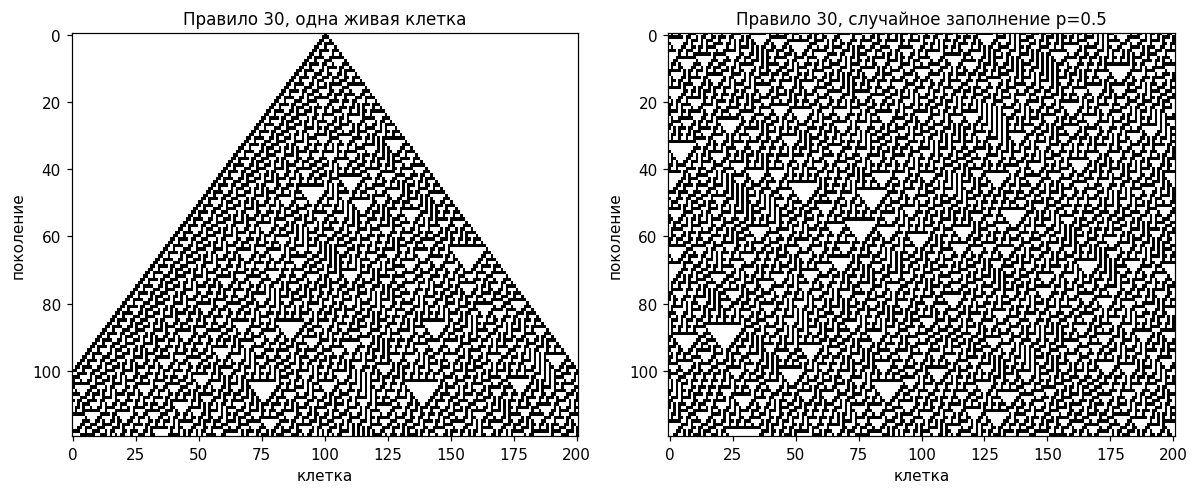

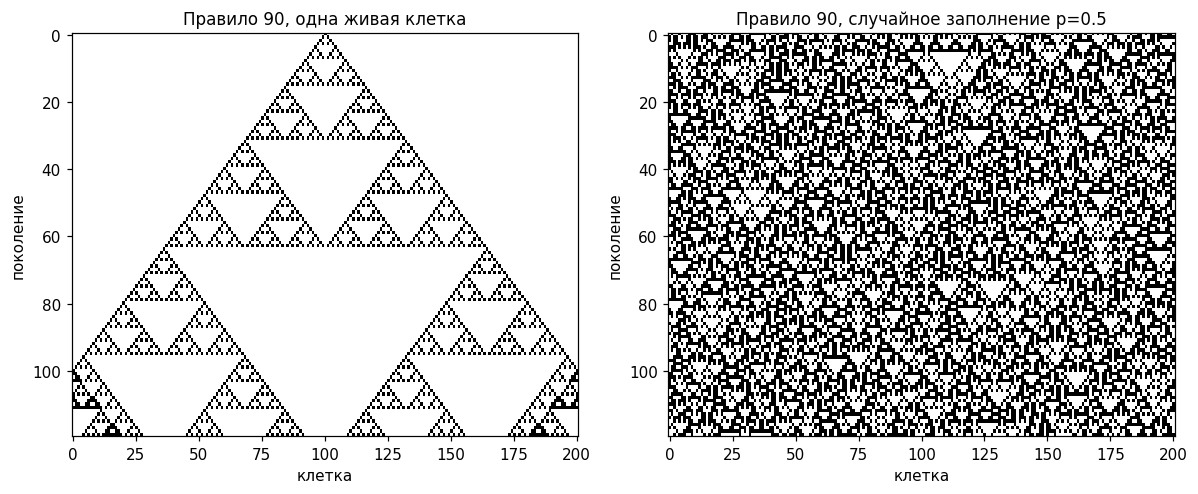

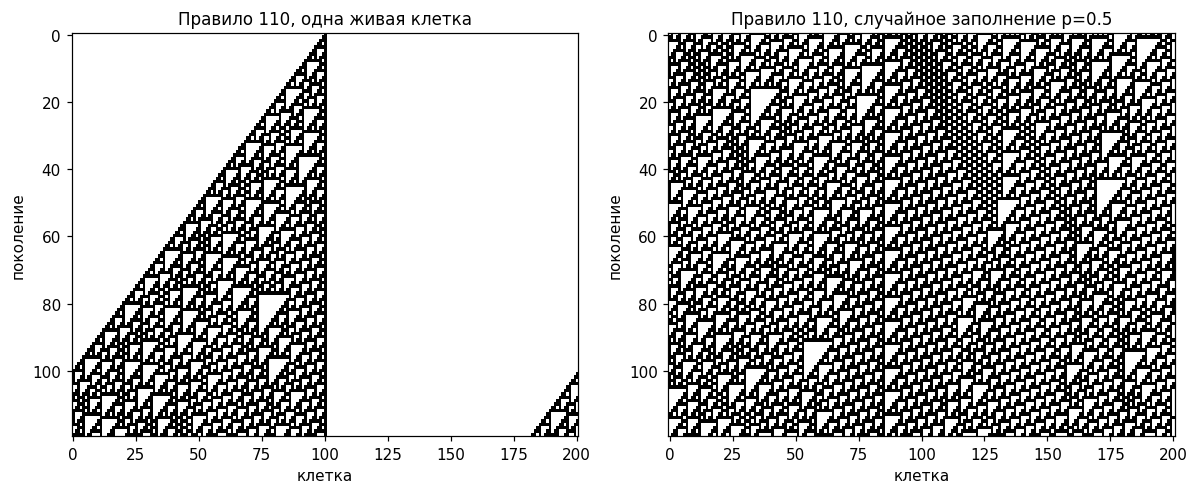

In [4]:
class ElemCAExperiment:
    """Экспериментальный модуль для одномерных автоматов: подготовка входов и отрисовка."""

    def __init__(self, width=201, steps=120):
        self.width = width
        self.steps = steps

    def plot_rule_pair(self, rule):
        grids = [
            ElementaryCA(rule, ElementaryCA.init_single(self.width)).evolve(self.steps),
            ElementaryCA(rule, ElementaryCA.init_random(self.width, p=0.5, seed=42)).evolve(self.steps),
        ]
        titles = [f'Правило {rule}, одна живая клетка',
                  f'Правило {rule}, случайное заполнение p=0.5']
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
        for ax, grid, title in zip(axes, grids, titles):
            ax.imshow(grid, cmap='binary', interpolation='nearest', aspect='auto')
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('клетка')
            ax.set_ylabel('поколение')
        fig.tight_layout()
        plt.show()


elem_exp = ElemCAExperiment()
for rule in (30, 90, 110):
    elem_exp.plot_rule_pair(rule)

## 2. Двумерный клеточный автомат «Жизнь» Конвея

Подсчёт живых соседей реализован свёрткой поля с ядром 3x3 (все элементы
единичные, кроме центрального нуля). Режим `constant` соответствует конечному
полю с мёртвыми границами. Правила B3/S23.

In [5]:
class GameOfLife:
    """Ядро игры «Жизнь» Конвея: один шаг (B3/S23) и детектор стабилизации."""

    KERNEL = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.int8)

    def __init__(self, grid):
        self.grid = np.asarray(grid, dtype=np.uint8).copy()

    def step(self):
        nb = convolve(self.grid.astype(np.int8), self.KERNEL, mode='constant', cval=0)
        birth = (self.grid == 0) & (nb == 3)
        survive = (self.grid == 1) & ((nb == 2) | (nb == 3))
        self.grid = (birth | survive).astype(np.uint8)
        return self.grid

    def population(self):
        return int(self.grid.sum())

    def run_until_stable(self, max_steps=1500, window=10):
        """Стабилизация: за окно из `window` поколений популяция постоянна
        (статика) либо строго чередуется между двумя значениями (период 2);
        отдельно фиксируется полное вымирание."""
        pops = [self.population()]
        for t in range(1, max_steps + 1):
            self.step()
            pops.append(self.population())
            if pops[-1] == 0:
                return t, self.grid, pops
            if len(pops) > window:
                tail = pops[-window:]
                if len(set(tail)) == 1:
                    return t, self.grid, pops
                if (len(set(tail)) == 2
                        and all(tail[i] != tail[i + 1] for i in range(window - 1))):
                    return t, self.grid, pops
        return max_steps, self.grid, pops

    @staticmethod
    def random_field(h, w, p, seed):
        rng = np.random.default_rng(seed)
        return (rng.random((h, w)) < p).astype(np.uint8)

### Кадры эволюции при разных начальных плотностях

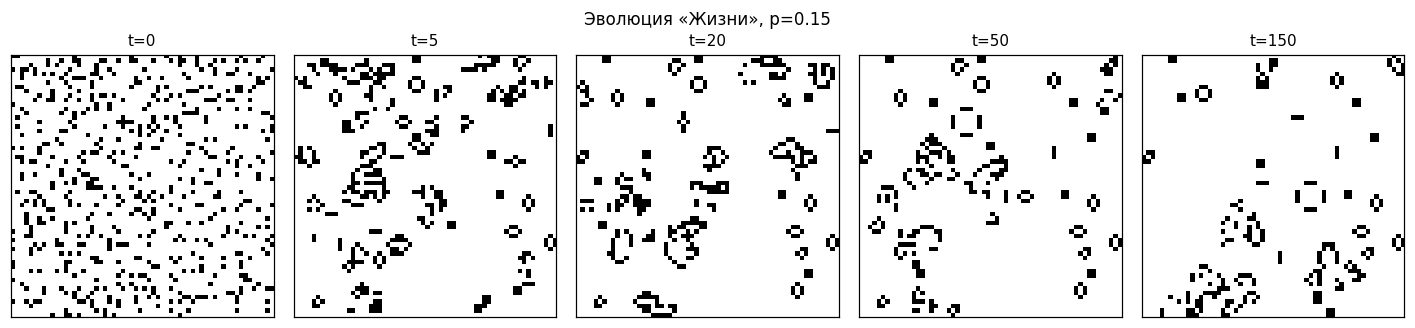

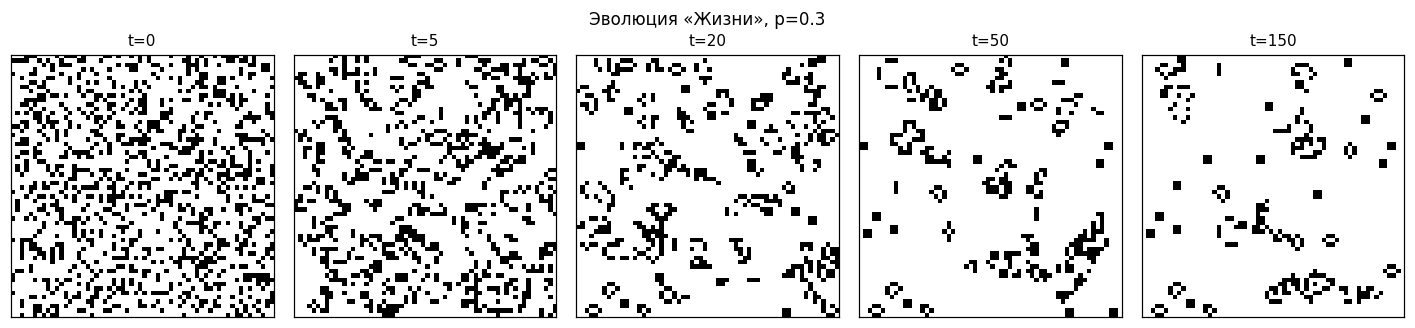

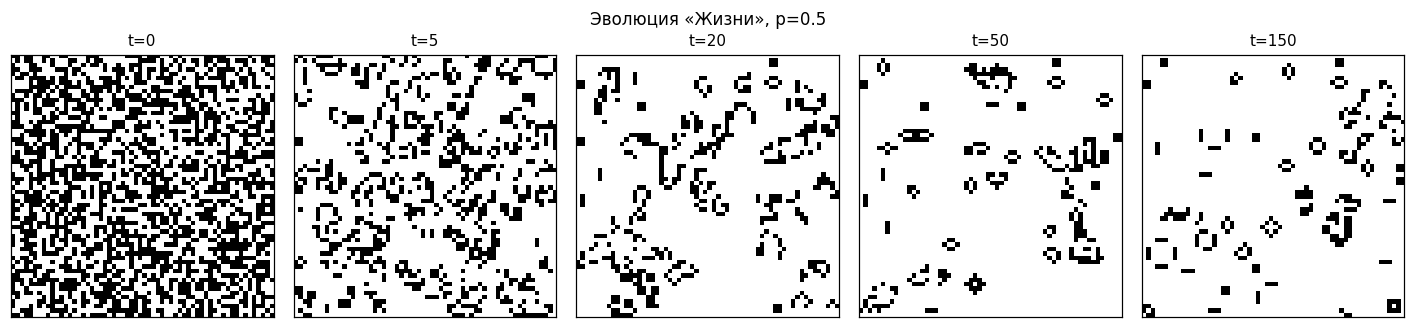

In [6]:
class DensityExperiment:
    """Серия запусков «Жизни» со случайным заполнением: время стабилизации
    в зависимости от плотности. Алгоритм берётся из ядра GameOfLife."""

    def __init__(self, densities, runs=10, size=60, max_steps=1500, window=10):
        self.densities = densities
        self.runs = runs
        self.size = size
        self.max_steps = max_steps
        self.window = window
        self.results = {}
        self.final_pops = {}

    def run(self):
        self.results = {p: [] for p in self.densities}
        self.final_pops = {p: [] for p in self.densities}
        for p in self.densities:
            for i in range(self.runs):
                seed = int(round(p * 1000)) * 100 + i
                field = GameOfLife.random_field(self.size, self.size, p, seed=seed)
                gen, _, pops = GameOfLife(field).run_until_stable(self.max_steps, self.window)
                self.results[p].append(gen)
                self.final_pops[p].append(pops[-1])
        return self.results

    def table(self):
        return pd.DataFrame({
            'p': self.densities,
            'T_среднее': [round(float(np.mean(self.results[p])), 1) for p in self.densities],
            'T_std': [round(float(np.std(self.results[p])), 1) for p in self.densities],
            'final_pop_среднее': [round(float(np.mean(self.final_pops[p])), 1) for p in self.densities],
        })

    def plot_T_of_p(self):
        ps = self.densities
        means = [np.mean(self.results[p]) for p in ps]
        stds = [np.std(self.results[p]) for p in ps]
        fig, ax = plt.subplots(figsize=(8, 4.8))
        ax.errorbar(ps, means, yerr=stds, marker='o', capsize=4, color='#1f77b4')
        ax.set_xlabel('начальная плотность p')
        ax.set_ylabel('среднее время стабилизации, поколений')
        ax.set_title('Зависимость среднего времени стабилизации от плотности')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_snapshots(p, seed, size=60, snapshot_steps=(0, 5, 20, 50, 150)):
        life = GameOfLife(GameOfLife.random_field(size, size, p, seed=seed))
        history = [life.grid.copy()]
        for _ in range(max(snapshot_steps)):
            life.step()
            history.append(life.grid.copy())
        n = len(snapshot_steps)
        fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.0))
        for ax, t in zip(axes, snapshot_steps):
            ax.imshow(history[t], cmap='binary', interpolation='nearest')
            ax.set_title(f't={t}', fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
        fig.suptitle(f'Эволюция «Жизни», p={p}', fontsize=11)
        fig.tight_layout()
        plt.show()

    @staticmethod
    def plot_population_curves(densities, size=60):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
        for p, color in zip(densities, colors):
            life = GameOfLife(GameOfLife.random_field(size, size, p, seed=int(p * 1000)))
            gen, _, pops = life.run_until_stable(max_steps=1500, window=10)
            ax.plot(pops, color=color, label=f'p={p}, стабилизация t={gen}')
        ax.set_xlabel('поколение')
        ax.set_ylabel('число живых клеток')
        ax.set_title('Численность живых клеток во времени')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


for p in (0.15, 0.30, 0.50):
    DensityExperiment.plot_snapshots(p, seed=int(p * 10000))

### Кривые численности живых клеток

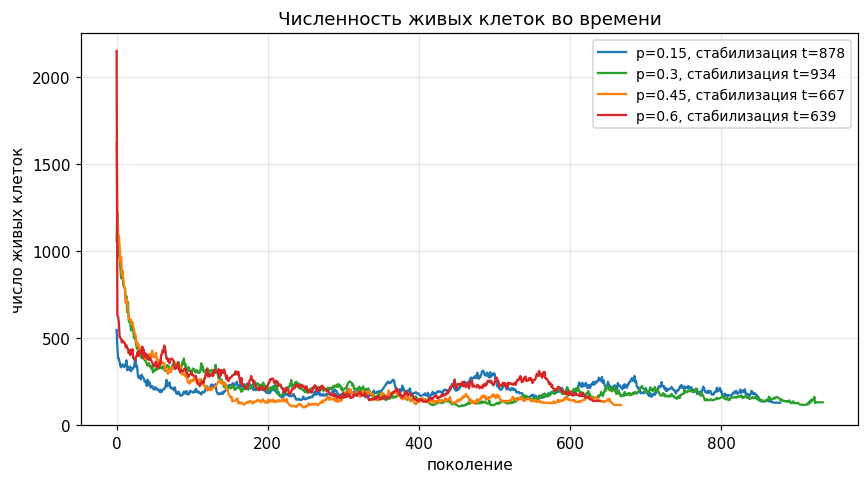

In [7]:
DensityExperiment.plot_population_curves([0.15, 0.30, 0.45, 0.60])

## 2.1, 2.2. Серия экспериментов: время стабилизации в зависимости от плотности

In [8]:
DENSITIES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
experiment = DensityExperiment(DENSITIES, runs=10, size=60)
experiment.run()

print(f"{'p':>5} {'T_среднее':>10} {'T_std':>8} {'final_pop':>10}")
for p in DENSITIES:
    ts = experiment.results[p]
    print(f'{p:>5.2f} {np.mean(ts):>10.1f} {np.std(ts):>8.1f} '
          f'{np.mean(experiment.final_pops[p]):>10.1f}')

    p  T_среднее    T_std  final_pop
 0.10      234.3    202.5       81.1
 0.20      755.5    393.8      106.1
 0.30      732.7    464.7      117.0
 0.40      702.8    444.0      129.4
 0.50      491.6    194.1      107.5
 0.60      637.0    276.7      111.7
 0.70      342.4    206.0       94.3


### Таблица результатов

In [9]:
experiment.table()

,p,T_среднее,T_std,final_pop_среднее
0,0.1,234.3,202.5,81.1
1,0.2,755.5,393.8,106.1
2,0.3,732.7,464.7,117.0
3,0.4,702.8,444.0,129.4
4,0.5,491.6,194.1,107.5
5,0.6,637.0,276.7,111.7
6,0.7,342.4,206.0,94.3


### График $T(p)$

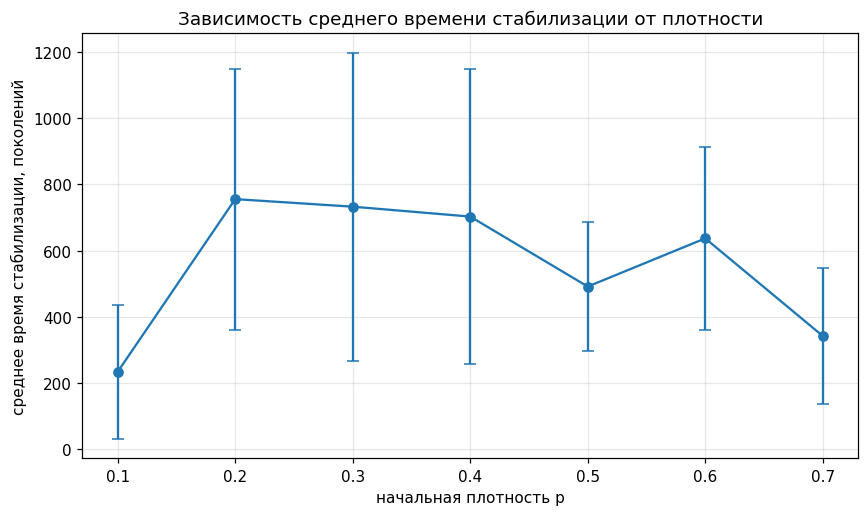

In [10]:
experiment.plot_T_of_p()

## 2.3. Классификация и подсчёт фигур

`PatternClassifier` разбивает поле на 8-связные компоненты, прогоняет каждую
через ядро `GameOfLife` и определяет тип (стабильный, периодический,
движущийся), сопоставляя ограничивающий прямоугольник с поворотами и
отражениями канонических шаблонов.

In [11]:
class PatternClassifier:
    """Классификация изолированных объектов поверх ядра GameOfLife."""

    CANONICAL = {
        'Блок':    ['##', '##'],
        'Улей':    ['.##.', '#..#', '.##.'],
        'Каравай': ['.##.', '#..#', '.#.#', '..#.'],
        'Лодка':   ['##.', '#.#', '.#.'],
        'Корыто':  ['.#.', '#.#', '.#.'],
        'Мигалка': ['###'],
        'Жаба':    ['.###', '###.'],
        'Маяк':    ['##..', '##..', '..##', '..##'],
        'Планер':  ['.#.', '..#', '###'],
    }

    def __init__(self):
        self.canonical_arrs = {name: self._all_symmetries(self._str_to_arr(rows))
                               for name, rows in self.CANONICAL.items()}

    @staticmethod
    def _str_to_arr(rows):
        h, w = len(rows), len(rows[0])
        arr = np.zeros((h, w), dtype=np.uint8)
        for i, row in enumerate(rows):
            for j, c in enumerate(row):
                arr[i, j] = 1 if c == '#' else 0
        return arr

    @staticmethod
    def _all_symmetries(arr):
        out, cur = [], arr
        for _ in range(4):
            out.append(cur)
            out.append(np.fliplr(cur))
            cur = np.rot90(cur)
        return out

    @staticmethod
    def _isolate(patch):
        if patch.sum() == 0:
            return patch
        rows = np.any(patch, axis=1); cols = np.any(patch, axis=0)
        r0, r1 = np.where(rows)[0][[0, -1]]
        c0, c1 = np.where(cols)[0][[0, -1]]
        return patch[r0:r1 + 1, c0:c1 + 1]

    def match_canonical(self, patch):
        for name, variants in self.canonical_arrs.items():
            for v in variants:
                if patch.shape == v.shape and np.array_equal(patch, v):
                    return name
        return None

    def classify_one(self, component, max_period=8, max_drift=4):
        pad = max_drift + 2
        h, w = component.shape
        field = np.zeros((h + 2 * pad, w + 2 * pad), dtype=np.uint8)
        field[pad:pad + h, pad:pad + w] = component
        initial = field.copy()
        initial_iso = self._isolate(initial)

        life = GameOfLife(field.copy())
        for period in range(1, max_period + 1):
            life.step()
            cur_iso = self._isolate(life.grid)
            if cur_iso.shape == initial_iso.shape and np.array_equal(cur_iso, initial_iso):
                kind = 'стабильный' if period == 1 else f'периодический T={period}'
                return kind, period, self.match_canonical(initial_iso)

        life = GameOfLife(field.copy())
        for period in range(1, max_period + 1):
            life.step()
            for dr in range(-max_drift, max_drift + 1):
                for dc in range(-max_drift, max_drift + 1):
                    if dr == 0 and dc == 0:
                        continue
                    shifted = np.roll(np.roll(initial, dr, axis=0), dc, axis=1)
                    if np.array_equal(life.grid, shifted):
                        return (f'движущийся T={period}', period,
                                self.match_canonical(initial_iso) or 'Планер?')
        return 'неклассифицированный', None, None

    @staticmethod
    def find_components(grid):
        structure = np.ones((3, 3), dtype=np.int8)
        labeled, n = label(grid, structure=structure)
        objs = []
        for i in range(1, n + 1):
            mask = (labeled == i)
            ys, xs = np.where(mask)
            r0, r1 = ys.min(), ys.max()
            c0, c1 = xs.min(), xs.max()
            patch = (grid[r0:r1 + 1, c0:c1 + 1]
                     * mask[r0:r1 + 1, c0:c1 + 1].astype(np.uint8))
            objs.append({'bbox': (r0, c0, r1, c1), 'patch': patch})
        return objs

    def classify_field(self, grid):
        summary = {'стабильный': 0, 'периодический': 0, 'движущийся': 0, 'прочее': 0}
        names, detailed = {}, []
        for obj in self.find_components(grid):
            kind, period, name = self.classify_one(obj['patch'])
            if kind.startswith('стабильный'):
                key = 'стабильный'
            elif kind.startswith('периодический'):
                key = 'периодический'
            elif kind.startswith('движущийся'):
                key = 'движущийся'
            else:
                key = 'прочее'
            summary[key] += 1
            if name:
                names[name] = names.get(name, 0) + 1
            detailed.append({'bbox': obj['bbox'], 'kind': kind,
                             'period': period, 'name': name, 'key': key})
        return summary, detailed, names

### Каталог канонических фигур и галерея

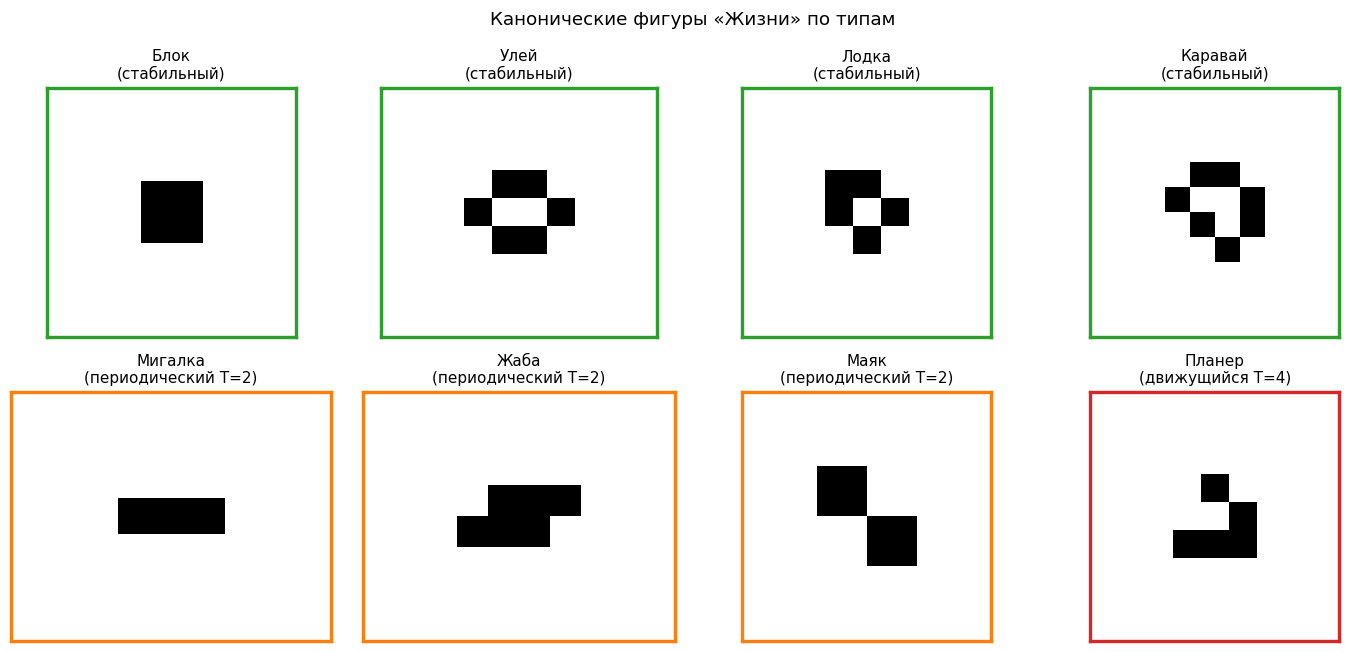

In [12]:
class ClassificationExp:
    """Экспериментальный модуль классификации: галерея образцов и анализ поля."""

    GALLERY = [
        ('Блок',     'стабильный',        ['##', '##']),
        ('Улей',     'стабильный',        ['.##.', '#..#', '.##.']),
        ('Лодка',    'стабильный',        ['##.', '#.#', '.#.']),
        ('Каравай',  'стабильный',        ['.##.', '#..#', '.#.#', '..#.']),
        ('Мигалка',  'периодический T=2', ['###']),
        ('Жаба',     'периодический T=2', ['.###', '###.']),
        ('Маяк',     'периодический T=2', ['##..', '##..', '..##', '..##']),
        ('Планер',   'движущийся T=4',    ['.#.', '..#', '###']),
    ]
    COLOR = {'стабильный': '#2ca02c', 'периодический T=2': '#ff7f0e', 'движущийся T=4': '#d62728'}

    def __init__(self):
        self.classifier = PatternClassifier()

    @staticmethod
    def _to_grid(rows, pad=3):
        h, w = len(rows), max(len(r) for r in rows)
        arr = np.zeros((h + 2 * pad, w + 2 * pad), dtype=np.uint8)
        for i, r in enumerate(rows):
            for j, c in enumerate(r):
                if c == '#':
                    arr[i + pad, j + pad] = 1
        return arr

    def plot_gallery(self):
        n = len(self.GALLERY); cols = 4; rows_n = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 3.0 * rows_n))
        for i, (name, kind, layout) in enumerate(self.GALLERY):
            ax = axes[i // cols, i % cols]
            ax.imshow(self._to_grid(layout, pad=3), cmap='binary', interpolation='nearest')
            for sp in ax.spines.values():
                sp.set_edgecolor(self.COLOR[kind]); sp.set_linewidth(2.2)
            ax.set_title(f'{name}\n({kind})', fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
        fig.suptitle('Канонические фигуры «Жизни» по типам')
        fig.tight_layout()
        plt.show()

    def plot_glider_motion(self):
        life = GameOfLife(self._to_grid(['.#.', '..#', '###'], pad=4))
        hist = [life.grid.copy()]
        for _ in range(4):
            life.step()
            hist.append(life.grid.copy())
        fig, axes = plt.subplots(1, 5, figsize=(13, 3.0))
        for ax, t, g in zip(axes, range(5), hist):
            ax.imshow(g, cmap='binary', interpolation='nearest')
            ax.set_title(f't={t}'); ax.set_xticks([]); ax.set_yticks([])
        fig.suptitle('Планер: период T=4 со сдвигом на 1 клетку по диагонали')
        fig.tight_layout()
        plt.show()

    def run(self, p=0.35, seed=2024, size=60):
        life = GameOfLife(GameOfLife.random_field(size, size, p, seed=seed))
        gen, final, pops = life.run_until_stable(max_steps=1500, window=10)
        summary, detailed, names = self.classifier.classify_field(final)
        print(f'Стабилизация на поколении {gen}')
        print(f'Всего объектов: {sum(summary.values())}')
        for k, v in summary.items():
            print(f'  {k}: {v}')
        print('Опознанные канонические паттерны:')
        for nm, c in sorted(names.items(), key=lambda x: -x[1]):
            print(f'  {nm}: {c}')
        return gen, final, summary, detailed, names

    @staticmethod
    def plot_field(final, detailed, gen):
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(final, cmap='binary', interpolation='nearest')
        cmap = {'стабильный': '#2ca02c', 'периодический': '#ff7f0e',
                'движущийся': '#d62728', 'прочее': '#7f7f7f'}
        for obj in detailed:
            r0, c0, r1, c1 = obj['bbox']
            ax.add_patch(plt.Rectangle((c0 - 0.5, r0 - 0.5), c1 - c0 + 1, r1 - r0 + 1,
                                       fill=False, edgecolor=cmap[obj['key']], linewidth=1.4))
        handles = [plt.Line2D([0], [0], color=c, lw=2, label=k) for k, c in cmap.items()]
        ax.legend(handles=handles, loc='upper right', fontsize=9)
        ax.set_title(f'Классификация объектов, стабилизация на поколении {gen}')
        ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout()
        plt.show()


class_exp = ClassificationExp()
class_exp.plot_gallery()

### Движение планера за 4 поколения

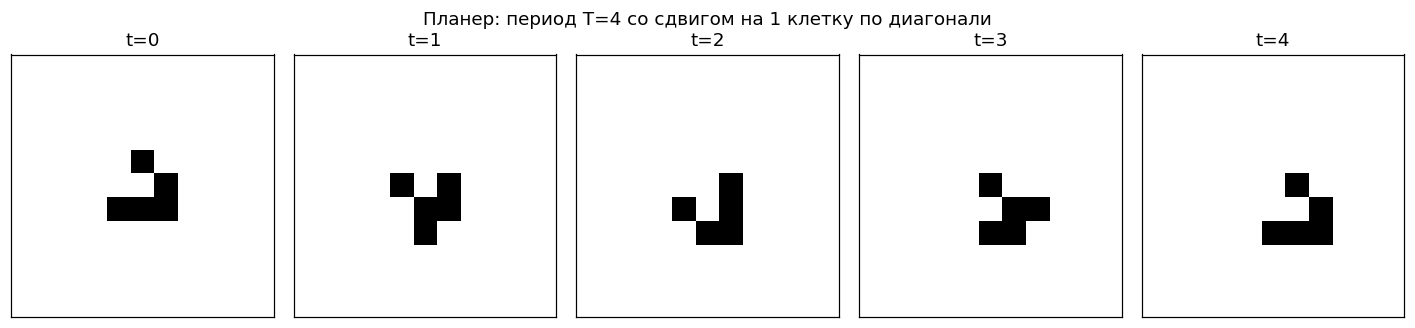

In [13]:
class_exp.plot_glider_motion()

### Запуск классификации на одном поле

Стабилизация на поколении 802
Всего объектов: 23
  стабильный: 16
  периодический: 7
  движущийся: 0
  прочее: 0
Опознанные канонические паттерны:
  Блок: 11
  Мигалка: 7
  Улей: 3
  Лодка: 1
  Каравай: 1


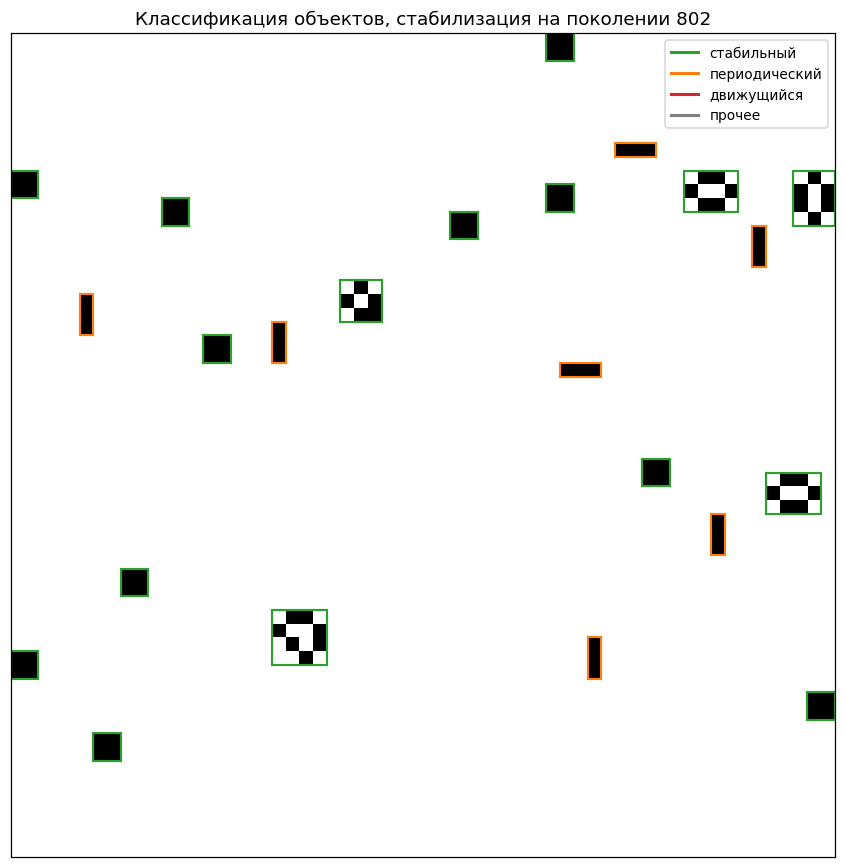

In [14]:
gen, final, summary, detailed, names = class_exp.run(p=0.35, seed=2024)
ClassificationExp.plot_field(final, detailed, gen)

In [15]:
df_objs = pd.DataFrame([
    {'Тип': 'Стабильные', 'Количество': summary['стабильный']},
    {'Тип': 'Периодические', 'Количество': summary['периодический']},
    {'Тип': 'Движущиеся', 'Количество': summary['движущийся']},
    {'Тип': 'Неклассифицированные', 'Количество': summary['прочее']},
    {'Тип': 'Всего', 'Количество': sum(summary.values())},
])
df_objs

,Тип,Количество
0,Стабильные,16
1,Периодические,7
2,Движущиеся,0
3,Неклассифицированные,0
4,Всего,23


In [16]:
df_names = pd.DataFrame(
    sorted(names.items(), key=lambda x: -x[1]),
    columns=['Паттерн', 'Количество']
)
df_names

,Паттерн,Количество
0,Блок,11
1,Мигалка,7
2,Улей,3
3,Лодка,1
4,Каравай,1


## Анализ результатов

Кривая среднего времени стабилизации имеет максимум в области средних
плотностей: при крайних значениях p система выходит на равновесие в несколько
раз быстрее. При низкой плотности поле быстро кристаллизуется на нескольких
устойчивых объектах, при высокой стремительно вымирает из-за перенаселения, а
в промежуточной зоне держится долгая хаотическая фаза с большим разбросом
времени стабилизации. Конечная плотность живых клеток слабо зависит от p и
определяется самим правилом B3/S23 и геометрией поля.

## Заключение

Реализованы элементарный одномерный автомат (`ElementaryCA`) и игра «Жизнь»
(`GameOfLife`) с детектором стабилизации, проведена серия экспериментов
(`DensityExperiment`) и классификация фигур (`PatternClassifier`). Максимум
времени стабилизации приходится на средние плотности (хаотическая фаза),
низкие дают быструю кристаллизацию, высокие массовое вымирание. Опознанные
объекты согласуются с известным частотным распределением фигур «Жизни».